# <font color="#084B8A"> Taller de herramientas computacionales </font>
## Python - Notas de clase  
***Facultad de Ciencias, UNAM***  
*Semestre 2024-2*  
Jorge Zavaleta Sánchez

## Cálculo simbólico

El cálculo simbólico se ocupa del cálculo de objetos matemáticos de forma simbólica. Esto significa que los objetos matemáticos se representan exactamente, no aproximadamente, y las expresiones matemáticas con variables no evaluadas se dejan en forma simbólica. Hay una gran variedad de sistemas algebraicos computacionales (**CAS**, computer algebra system, véase la siguiente [liga](https://es.wikipedia.org/wiki/Sistema_algebraico_computacional)) y dentro de *Python* se tiene disponible el módulo ```SymPy``` para este fin. Para cargar el módulo se usará la siguiente instrucción.

In [ ]:
import sympy

Por ejemplo, como hemos visto antes, si se quiere evaluar la raíz cuadrada podemos usar las funciones definidas en los modulos `math` o `numpy`, con los cuales se obtiene una aproximación en la mayoría de los casos. Así, al calcular $\sqrt{8}$ se obtiene,

In [ ]:
import math
math.sqrt(8)

2.8284271247461903

la cual es una aproximación, ya que $\sqrt{8}$ es un número irracional y no se puede representar de forma exacta en la computadora. Por otro lado, observe que $\sqrt{8} = \sqrt{4\cdot2} = 2\sqrt{2}$, lo cual no se puede deducir de la salida del código anterior. Si se utiliza el cáculo simbólico a través de `sympy`, en lugar de realizar la evaluación de las expresiones, se realizará su simplificación. De este manera,

In [ ]:
sympy.sqrt(8)

2*sqrt(2)

que es una representación exacta de $\sqrt{8}$. Los sistemas de cálculo simbólico como `sympy` son capaces de calcular expresiones simbólicas con variables.

Las variables *simbólicas* deben ser definidas antes de que se utilicen y son definidas usando `symbols`.

In [ ]:
x, y = sympy.symbols('x y')
expr = x + 2*y
expr

x + 2*y

Tenga en cuenta que se escribio `x + 2*y` tal como se haría si `x` e `y` fueran variables normales de *python*. Pero en este caso, en lugar de evaluar algo, la expresión permanece como `x + 2*y`. Ahora se mostrarán otros ejemplos de se uso:

In [ ]:
expr + 1

x + 2*y + 1

In [ ]:
expr - x

2*y

In [ ]:
x*expr

x*(x + 2*y)

De los ejemplos anteriores se observan diferentes comportamientos en los resultados de las operaciones realizadas. En algunos casos las expresiones se quedan tal cual se escriben, pero en algunos casos se realiza una simplificación, como en el caso de la segunda expresión. Aunque hay simplicaciones que se realizan de forma automática, no siempre se realizan, como en la última expresión. Dependiendo de como se quiere mostrar el resultado, se pueden usar las funciones `expand` y `factor`, para expandir y factorizar una expresión, respectivamente.

In [ ]:
expand_expr = sympy.expand(x*expr)
expand_expr

x**2 + 2*x*y

In [ ]:
sympy.factor(expand_expr)

x*(x + 2*y)

El poder real de un sistema de cálculo simbólico como `sympy` es la capacidad de realizar todo tipo de cálculos simbólicamente. `sympy` puede:
* simplificar expresiones,
* calcular derivadas, integrales y límites,
* resolver ecuaciones,
* trabajar con matrices,

y mucho más, y hacerlo todo simbólicamente.

Incluye módulos para trazar, imprimir (como una salida impresa en 2D de fórmulas matemáticas o $\LaTeX$), generación de código, física, estadística, combinatoria, teoría de números, geometría, lógica y más. Aquí hay una pequeña muestra del tipo de poder simbólico que `sympy` es capaz.

Para calcular la derivada de $\sin(x)e^{x}$ se usa la función `diff`.

In [ ]:
x, t = sympy.symbols('x t')
sympy.diff(sympy.sin(x)*sympy.exp(x), x)

exp(x)*sin(x) + exp(x)*cos(x)

o la derivada de cualquier orden al especificar un tercer argumento, por ejemplo, la segunda derivada de $\sin(x)e^{x}$

In [ ]:
sympy.diff(sympy.sin(x)*sympy.exp(x), x, 2)

2*exp(x)*cos(x)

También es posible calcular la integral de la primera derivada de $\sin(x)e^{x}$, *i.e.*, $\displaystyle\int e^{x}\left(\sin(x) + \cos(x)\right)\,\mathrm{d}x$, para ello se usa la función `integrate`.

In [ ]:
sympy.integrate(sympy.exp(x)*sympy.sin(x) + sympy.exp(x)*sympy.cos(x), x)

exp(x)*sin(x)

o también se pueden calcular integrales definidas como, $\displaystyle\int_{-\infty}^{\infty}e^{-x^2}\,\mathrm{d}x$

In [ ]:
sympy.integrate(sympy.exp(-x**2), (x, -sympy.oo, sympy.oo))

sqrt(pi)

Encontrar límites mediante la función `limit`, como por ejemplo, $\displaystyle\lim_{x\to0}\frac{\sin(x)}{x}$,

In [ ]:
sympy.limit(sympy.sin(x)/x, x, 0)

1

Resolver la ecuación $x^2-2=0$ (encontrar los ceros) usando la función `solve`.

In [ ]:
sympy.solve(x**2 - 2, x)

[-sqrt(2), sqrt(2)]

Resolver ecuaciones diferenciales con `dsolve`, como por ejemplo, $y''-y=e^t$,

In [ ]:
y = sympy.Function('y')
sympy.dsolve(sympy.Eq(y(t).diff(t,t)-y(t),sympy.exp(t)),y(t))

Eq(y(t), C2*exp(-t) + (C1 + t/2)*exp(t))

Encontrar los eigenvalores y eigenvectores de una matriz, como por ejemplo, los eigenvalores y eigenvectores de $$\begin{pmatrix}1 & 2 \\ 2 & 2 \end{pmatrix}$$ se pueden calcular de la siguiente manera.

In [ ]:
sympy.Matrix([[1, 2], [2, 2]]).eigenvals()

{3/2 - sqrt(17)/2: 1, 3/2 + sqrt(17)/2: 1}

In [ ]:
sympy.Matrix([[1, 2], [2, 2]]).eigenvects()

[(3/2 - sqrt(17)/2,
  1,
  [Matrix([
   [-sqrt(17)/4 - 1/4],
   [                1]])]),
 (3/2 + sqrt(17)/2,
  1,
  [Matrix([
   [-1/4 + sqrt(17)/4],
   [                1]])])]

Una de la funcionalidades con las que se cuenta es poder imprimir en código $\LaTeX$ con la función `latex`. Por ejemplo, si se quiere convertir $\displaystyle\int\limits_{0}^{\pi} \cos^{2}{\left(x \right)}\, \mathrm{d}x$

In [ ]:
s = sympy.latex(sympy.Integral(sympy.cos(x)**2, (x, 0, sympy.pi)))
print(type(s))
print(s)

<class 'str'>
\int\limits_{0}^{\pi} \cos^{2}{\left(x \right)}\, dx


También es posible interacturar con otros elementos vistos de python. Por ejemplo, podemos convertir una expresión dada como una cadena (`str`) a una expresión simbólica mediante `sympify`.

In [ ]:
expr = sympy.sympify(input('Dame una expresión: '))
expr

Dame una expresión: abs(x) - x**2


-x**2 + Abs(x)

**Nota**: Hay que tener cuidado de que las expresiones dadas como cadenas se formen usando los operadores aritméticos propios de python y los nombres de las funciones sean los utilizados en `sympy`. Luego, si es necesario evaluar una expresión podemos hacer uso del método `evalf` para obtener su valor númerico aproximado.

In [ ]:
v = float(input('Dame un valor donde quieres evaluar la expresión anterior: '))
print(f'{expr} en x = {v} es {expr.evalf(subs={x: v}): .4f}')

Dame un valor donde quieres evaluar la expresión anterior: 2.5
-x**2 + Abs(x) en x = 2.5 es -3.7500


También es posible convertir las expresiones a expresiones que puedan ser evaluadas numéricamente mediante la función `lambdify`, para que sea óptima su ejecución cuando se necesitan evaluar muchas veces una expresión.

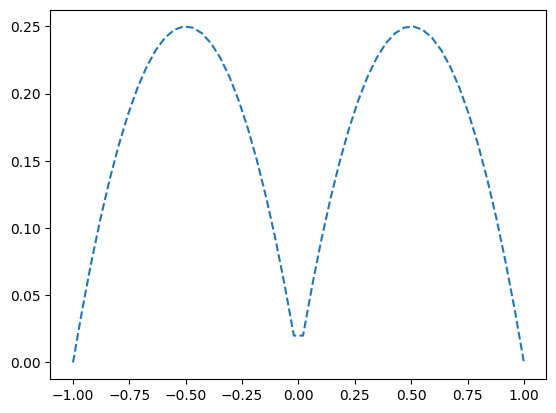

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
f = sympy.lambdify(x, expr, 'numpy')
e = np.linspace(-1, 1)
plt.plot(e, f(e), '--')
plt.show()

**Nota**: Es posible usar la cadena `'math'` como el tercer argumento de la función `lambdify` para generar una expresión con las funciones del módulo `math`.

Revise la siguiente [liga](https://docs.sympy.org/latest/tutorial/index.html) como referencia para una guía completa del uso de `sympy`.

### Ejemplo 19 (Graficar los ceros de una función con ```SymPy```)

Dada una función continua $f\colon[a,b]\subset\mathbb{R}\to \mathbb{R}$, se quiere encontrar un cero o raíz de $f$. Esto es, se quiere saber si existe $x_{0}\in[a,b]$ tal que $f(x_{0}) = 0$. Se utilizaran las funciones del módulo `sympy` para buscar los ceros de una función $f$ dada como una cadena y se mostrara(n) gráficamente.

In [ ]:
from sympy.plotting import plot  # Graficas con sympy
from IPython.display import display  # Desplegar variables simbolicas con formato
sympy.init_printing()  # Garantiza la impresion en modo matematico

Dame la expresión para la función f: sin(exp(t**2))
Cual es la variable independiente: t

Las raices reales de la función : 


   ⎛ ⎛ 2⎞⎞
   ⎜ ⎝t ⎠⎟
sin⎝ℯ    ⎠


son: 


⎡   ________    ________⎤
⎣-╲╱ log(π) , ╲╱ log(π) ⎦

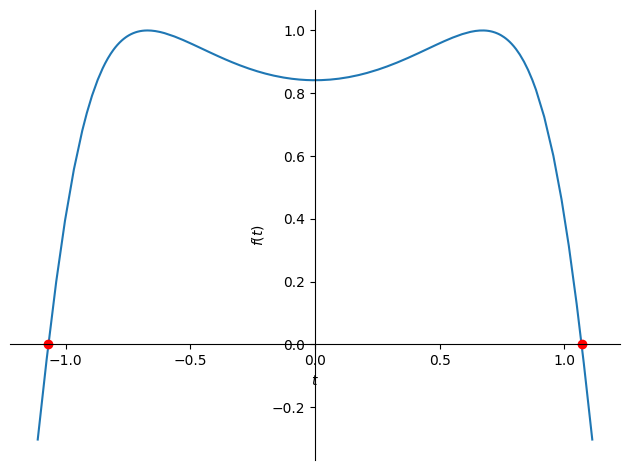

In [ ]:
# Se piden los datos
expr = sympy.sympify(input('Dame la expresión para la función f: '))
var = sympy.symbols(input('Cual es la variable independiente: '))

# Se obtinen las raices reales
raiz = sympy.solve(expr, var)
raiz = list(filter(lambda x: abs(complex(x.evalf()).imag) < 1e-16, raiz))

# Cuando hay raices reales se muestra la grafica
if len(raiz) > 0:
    # Se muestran las raices de forma simbolica
    print('\nLas raices reales de la función : ', sep='\n\n')
    display(expr)
    print('\nson: ', sep='\n\n')
    display(raiz)

    # Grafica de la funcion
    ## Variables para los intervalos de graficacion
    d = max(raiz) - min(raiz)
    radio = 0.02*d  # Vecindad alrededor de una raiz
    if d <= 1.:
        p_size, radio = 0.01, 1.
    raiz = list(map(lambda x: complex(x.evalf()).real, raiz))  # Valores numericos de las raices

    ## Grafica
    graf = plot(expr, (var, min(raiz)-radio, max(raiz)+radio),
                markers=[{'args': [raiz, [0]*len(raiz), 'ro']}])  # Funcion
else:
    print('No hay raíces reales')